In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [25]:
! python transient_run.py

steady: bias=0.0, nmx=0, iteration=1, amax=2.012561404772428e-06, vmax=0.46850889028044407
steady: bias=0.0, nmx=0, iteration=2, amax=7.867592339851777e-08, vmax=0.4528466671351604
steady: bias=0.0, nmx=0, iteration=3, amax=7.316924577486799e-08, vmax=0.4279146778335746
steady: bias=0.0, nmx=0, iteration=4, amax=6.715260002154298e-08, vmax=0.4044232881682896
steady: bias=0.0, nmx=0, iteration=5, amax=6.083361068223556e-08, vmax=0.382448978140891
steady: bias=0.0, nmx=0, iteration=6, amax=5.4518047311620666e-08, vmax=0.3620288744612489
steady: bias=0.0, nmx=0, iteration=7, amax=4.874630450233913e-08, vmax=0.3431597202447314
steady: bias=0.0, nmx=0, iteration=8, amax=4.315959767740649e-08, vmax=0.32579908385027223
steady: bias=0.0, nmx=0, iteration=9, amax=3.7905057774231646e-08, vmax=0.30986905471494497
steady: bias=0.0, nmx=0, iteration=10, amax=3.309204686089559e-08, vmax=0.29526237016853746
steady: bias=0.0, nmx=0, iteration=11, amax=2.911880368150067e-08, vmax=0.2818504736260733
ste

In [3]:
output_folder = Path("lww_output_transient")
state_files = {
    "potential": output_folder / "lww_pypoten.csv",
    "density": output_folder / "lww_pydensity.csv",
    "wigner": output_folder / "lww_pywigner.csv",
    "wigner_ss": output_folder / "lww_pywigner_ss.csv",
}

missing_state_files = [name for name, path in state_files.items() if not path.exists()]
if missing_state_files:
    raise FileNotFoundError(f"Missing state CSV files: {missing_state_files}")

potential = pd.read_csv(state_files["potential"], header=None).values.flatten()
density = pd.read_csv(state_files["density"], header=None).values.flatten()
wigner_flat = pd.read_csv(state_files["wigner"], header=None).values.flatten()
wigner_ss_flat = pd.read_csv(state_files["wigner_ss"], header=None).values.flatten()

Nx = len(density)
N = len(wigner_flat) // Nx
if len(wigner_flat) % Nx != 0 or len(wigner_ss_flat) % Nx != 0:
    raise ValueError("Wigner arrays cannot be reshaped using inferred Nx")

wigner = wigner_flat.reshape(Nx, N)
wigner_ss = wigner_ss_flat.reshape(Nx, N)

box = 550.0
x = np.linspace(0.0, box, Nx)
delx = box / (Nx - 1)
delk = np.pi / (delx * N)
k = (np.arange(N) - N / 2 + 0.5) * delk

state_summary = pd.DataFrame(
    {
        "quantity": ["potential", "density", "wigner", "wigner_ss"],
        "shape": [potential.shape, density.shape, wigner.shape, wigner_ss.shape],
        "min": [potential.min(), density.min(), wigner.min(), wigner_ss.min()],
        "max": [potential.max(), density.max(), wigner.max(), wigner_ss.max()],
    }
)

display(state_summary)

,quantity,shape,min,max
0,potential,"(86,)",-3.995744e-01,0.222015
1,density,"(86,)",8.398428e-09,0.000003
2,wigner,"(86, 72)",-4.623081e-05,0.000357
3,wigner_ss,"(86, 72)",-3.399112e-06,0.000243


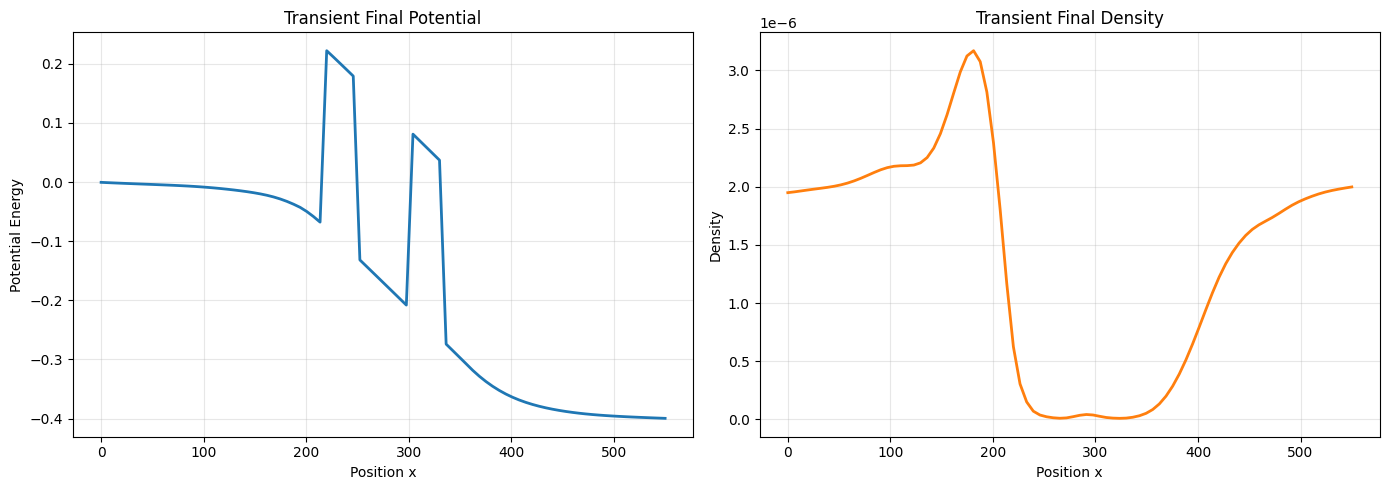

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, potential, color="tab:blue", linewidth=2)
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("Potential Energy")
axes[0].set_title("Transient Final Potential")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, density, color="tab:orange", linewidth=2)
axes[1].set_xlabel("Position x")
axes[1].set_ylabel("Density")
axes[1].set_title("Transient Final Density")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

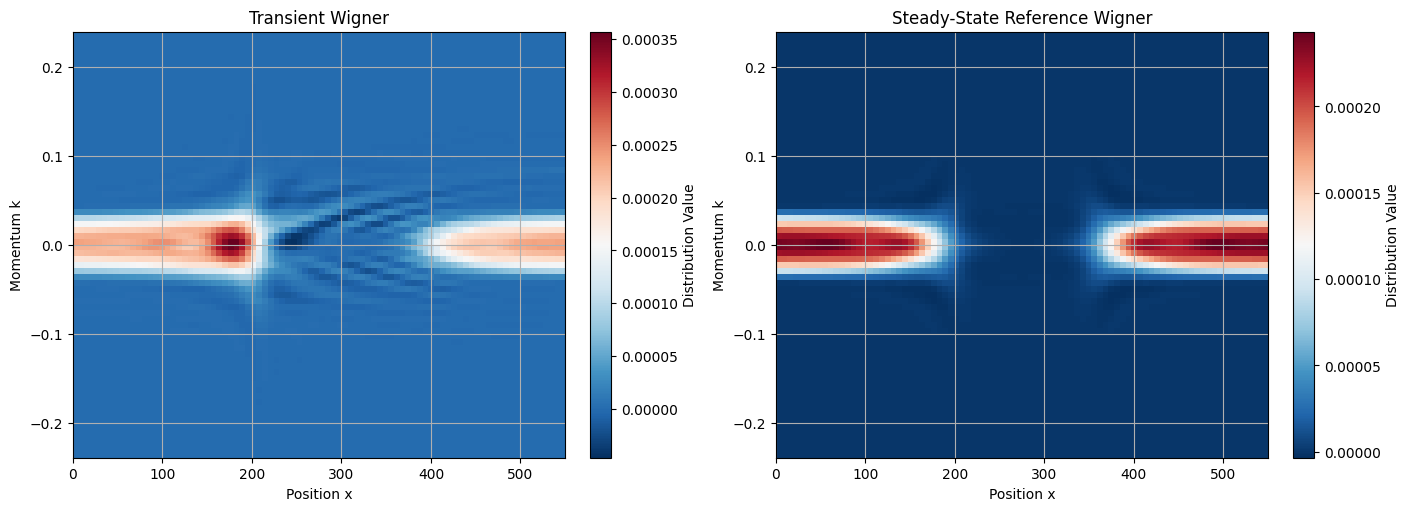

In [10]:
output_folder = Path("lww_output_transient")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im0 = axes[0].imshow(
    wigner.T,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), k.min(), k.max()],
    cmap="RdBu_r",
)
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("Momentum k")
axes[0].set_title("Transient Wigner")
fig.colorbar(im0, ax=axes[0], label="Distribution Value")

im1 = axes[1].imshow(
    wigner_ss.T,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), k.min(), k.max()],
    cmap="RdBu_r",
)
axes[1].set_xlabel("Position x")
axes[1].set_ylabel("Momentum k")
axes[1].set_title("Steady-State Reference Wigner")
fig.colorbar(im1, ax=axes[1], label="Distribution Value")

plt.show()

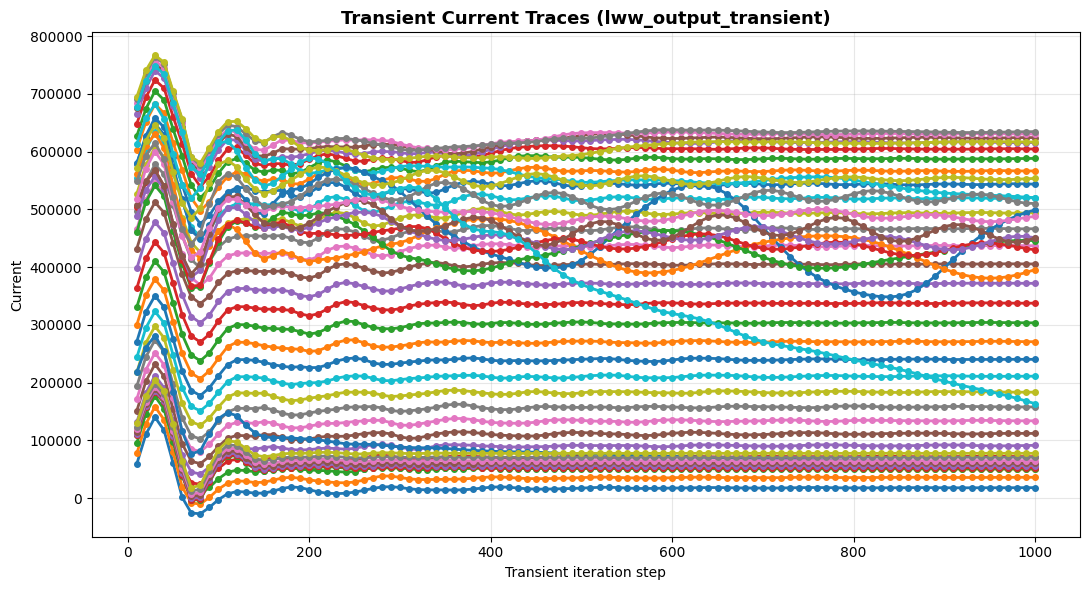

,bias,file,samples,first_itstep,last_itstep,first_current,last_current
0,0.008,lww_tcurl_0.0080.csv,100,10,1000,59347.853918,18171.789804
1,0.016,lww_tcurl_0.0160.csv,100,10,1000,77490.405527,36065.532919
2,0.024,lww_tcurl_0.0240.csv,100,10,1000,95446.718096,53935.803790
3,0.032,lww_tcurl_0.0320.csv,100,10,1000,113321.695564,71783.580255
4,0.040,lww_tcurl_0.0400.csv,100,10,1000,131286.110704,91453.448023
5,0.048,lww_tcurl_0.0480.csv,100,10,1000,151266.261840,112017.685894
6,0.056,lww_tcurl_0.0560.csv,100,10,1000,171545.841299,133903.832133
7,0.064,lww_tcurl_0.0640.csv,100,10,1000,193712.823642,157929.673142
8,0.072,lww_tcurl_0.0720.csv,100,10,1000,217807.750557,183536.264404
9,0.080,lww_tcurl_0.0800.csv,100,10,1000,243575.104286,211167.839988


In [26]:
output_folder = Path("lww_output_transient")
def tcurl_bias(csv_path):
    return float(csv_path.stem.replace("lww_tcurl_", ""))


tcurl_files = sorted(output_folder.glob("lww_tcurl_0*.csv"), key=tcurl_bias)
if not tcurl_files:
    raise FileNotFoundError(f"No lww_tcurl_*.csv files found in {output_folder}")

tcurl_summary = []
fig, ax = plt.subplots(figsize=(11, 6))

for csv_file in tcurl_files[:-1]:
    bias = tcurl_bias(csv_file)
    trace = pd.read_csv(csv_file)
    if not {"itstep", "current"}.issubset(trace.columns):
        raise ValueError(f"{csv_file.name} must contain itstep and current columns")

    if len(trace):
        ax.plot(
            trace["itstep"],
            trace["current"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=f"bias = {bias:.3f}",
        )

    tcurl_summary.append(
        {
            "bias": bias,
            "file": csv_file.name,
            "samples": len(trace),
            "first_itstep": trace["itstep"].iloc[0] if len(trace) else np.nan,
            "last_itstep": trace["itstep"].iloc[-1] if len(trace) else np.nan,
            "first_current": trace["current"].iloc[0] if len(trace) else np.nan,
            "last_current": trace["current"].iloc[-1] if len(trace) else np.nan,
        }
    )

ax.set_xlabel("Transient iteration step")
ax.set_ylabel("Current")
ax.set_title(f"Transient Current Traces ({output_folder})", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
# ax.legend(title="Bias")
plt.tight_layout()
plt.show()

tcurl_summary_df = pd.DataFrame(tcurl_summary)
display(tcurl_summary_df)

In [ ]:
# Wider quantum well depth (100 nm instead of 50 nm)
! python transient_run_v2.py

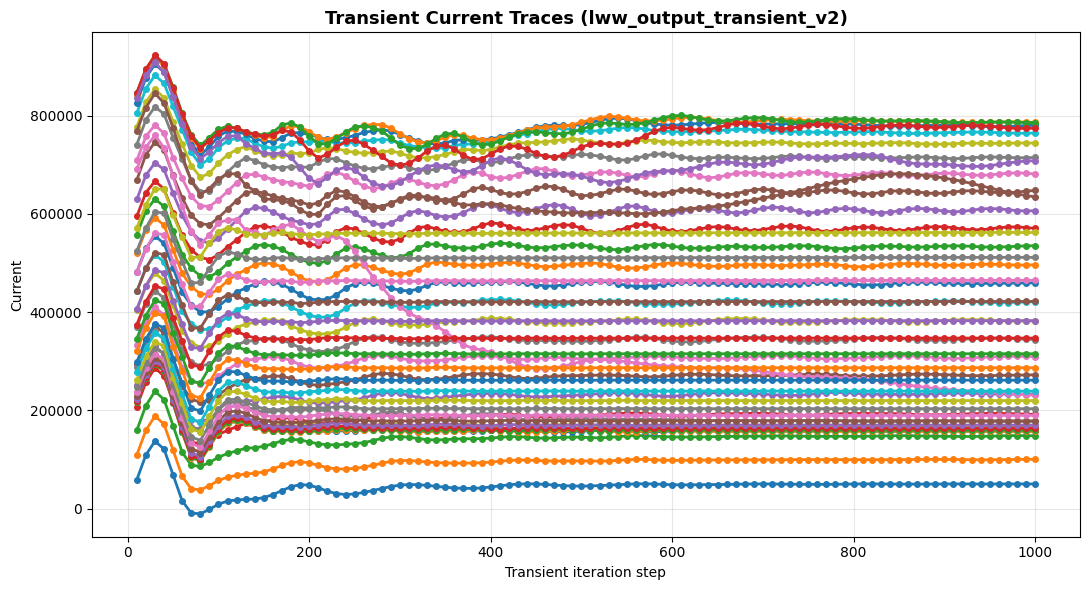

,bias,file,samples,first_itstep,last_itstep,first_current,last_current
0,0.008,lww_tcurl_0.0080.csv,100,10,1000,59185.160567,50460.949471
1,0.016,lww_tcurl_0.0160.csv,100,10,1000,109599.401849,100536.270654
2,0.024,lww_tcurl_0.0240.csv,100,10,1000,159823.727567,148506.578311
3,0.032,lww_tcurl_0.0320.csv,100,10,1000,207768.668994,192110.537913
4,0.040,lww_tcurl_0.0400.csv,100,10,1000,251591.764179,233409.544198
5,0.048,lww_tcurl_0.0480.csv,100,10,1000,293647.298142,272520.315210
6,0.056,lww_tcurl_0.0560.csv,100,10,1000,333012.427915,309568.797237
7,0.064,lww_tcurl_0.0640.csv,100,10,1000,369166.627502,344256.081779
8,0.072,lww_tcurl_0.0720.csv,100,10,1000,404184.299178,382042.312357
9,0.080,lww_tcurl_0.0800.csv,100,10,1000,442479.016228,421280.926053


In [17]:
output_folder = Path("lww_output_transient_v2")
def tcurl_bias(csv_path):
    return float(csv_path.stem.replace("lww_tcurl_", ""))


tcurl_files = sorted(output_folder.glob("lww_tcurl_0*.csv"), key=tcurl_bias)
if not tcurl_files:
    raise FileNotFoundError(f"No lww_tcurl_*.csv files found in {output_folder}")

tcurl_summary_v2 = []
fig, ax = plt.subplots(figsize=(11, 6))

for csv_file in tcurl_files[:-1]:
    bias = tcurl_bias(csv_file)
    trace = pd.read_csv(csv_file)
    if not {"itstep", "current"}.issubset(trace.columns):
        raise ValueError(f"{csv_file.name} must contain itstep and current columns")

    if len(trace):
        ax.plot(
            trace["itstep"],
            trace["current"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=f"bias = {bias:.3f}",
        )

    tcurl_summary_v2.append(
        {
            "bias": bias,
            "file": csv_file.name,
            "samples": len(trace),
            "first_itstep": trace["itstep"].iloc[0] if len(trace) else np.nan,
            "last_itstep": trace["itstep"].iloc[-1] if len(trace) else np.nan,
            "first_current": trace["current"].iloc[0] if len(trace) else np.nan,
            "last_current": trace["current"].iloc[-1] if len(trace) else np.nan,
        }
    )

ax.set_xlabel("Transient iteration step")
ax.set_ylabel("Current")
ax.set_title(f"Transient Current Traces ({output_folder})", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
# ax.legend(title="Bias")
plt.tight_layout()
plt.show()

tcurl_summary_df_v2 = pd.DataFrame(tcurl_summary_v2)
display(tcurl_summary_df_v2)

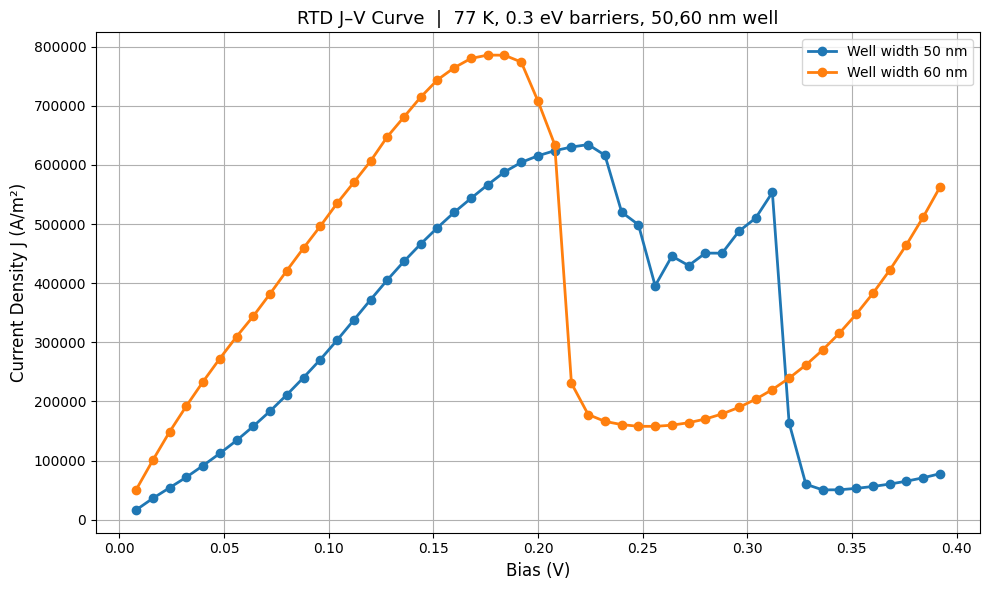

In [22]:
plt.plot(
    tcurl_summary_df["bias"],
    tcurl_summary_df["last_current"],
    marker="o",
    linewidth=2,
    label="Well width 50 nm",
)
plt.plot(
    tcurl_summary_df_v2["bias"],
    tcurl_summary_df_v2["last_current"],
    marker="o",
    linewidth=2,
    label="Well width 60 nm",
)
plt.xlabel("Bias (V)", fontsize=12)
plt.ylabel("Current Density J (A/m²)", fontsize=12)
plt.title("RTD J–V Curve  |  77 K, 0.3 eV barriers, 50,60 nm well", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()